<a href="https://colab.research.google.com/github/DiFedorchuk/ML_Course/blob/main/HW_2_4_kNN_%D0%9A%D1%80%D0%BE%D1%81%D0%B2%D0%B0%D0%BB%D1%96%D0%B4%D0%B0%D1%86%D1%96%D1%8F_%D1%96_%D1%82%D1%8E%D0%BD%D0%B8%D0%BD%D0%B3_%D0%B3%D1%96%D0%BF%D0%B5%D1%80%D0%BF%D0%B0%D1%80%D0%B0%D0%BC%D0%B5%D1%82%D1%80%D1%96%D0%B2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням kNearestNeighboors, знайдемо оптимальні гіперпараметри для цього методу і зробимо базові ансамблі. Це дасть змогу порівняти перформанс моделі з попередніми вивченими методами.

0. Зчитайте дані `train.csv` та зробіть препроцесинг використовуючи написаний Вами скрипт `process_bank_churn.py` так, аби в результаті отримати дані в розбитті X_train, train_targets, X_val, val_targets для експериментів.

  Якщо Вам не вдалось реалізувати в завданні `2.3. Дерева прийняття рішень` скрипт `process_bank_churn.py` - можна скористатись готовим скриптом з запропонованого рішення того завдання.

In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
import os
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.neighbors import KNeighborsClassifier
%matplotlib inline

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
raw_df = pd.read_csv("/content/drive/MyDrive/Courses/Machine Learning/Data/Bank Customer Churn Prediction/train.csv")

In [4]:
from process_bank_churn import preprocess_data

In [5]:
data = preprocess_data(raw_df)

In [6]:
X_train = data['train_inputs']
train_targets = data['train_targets']
X_val = data['val_inputs']
val_targets  = data['val_targets']

input_cols = data['input_cols']
scaler = data['scaler']
encoder = data['encoder']

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {train_targets.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_val shape: {val_targets.shape}")

X_train shape: (12000, 14)
y_train shape: (12000,)
X_val shape: (3000, 14)
y_val shape: (3000,)


In [7]:
# Видалимо колонку ID
if 'id' in X_train.columns:
    X_train = X_train.drop('id', axis=1)
    X_val = X_val.drop('id', axis=1)
    input_cols = [col for col in input_cols if col != 'id']
    print("Successfully removed 'id' column from X_train, X_val, and input_cols.")
else:
    print("'id' column not found in X_train.")

Successfully removed 'id' column from X_train, X_val, and input_cols.


1. Навчіть на цих даних класифікатор kNN з параметрами за замовченням і виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах. Зробіть заключення про отриману модель: вона хороша/погана, чи є high bias/high variance?

In [12]:
knn = KNeighborsClassifier()
knn.fit(X_train, train_targets)
y_train_pred_proba = knn.predict_proba(X_train)[:, 1]
y_val_pred_proba = knn.predict_proba(X_val)[:, 1]

roc_auc_train = roc_auc_score(train_targets, y_train_pred_proba)
roc_auc_val = roc_auc_score(val_targets, y_val_pred_proba)
print(f"AUROC on training set: {roc_auc_train:.4f}")
print(f"AUROC on validation set: {roc_auc_val:.4f}")

AUROC on training set: 0.9559
AUROC on validation set: 0.8526


Висновок:AUROC на тренувальному наборі 0.95, на валідаційному 0,85, можемо зробити висновок що хороша, не має сильних ознак перенавчання чи недонавчання

2. Використовуючи `GridSearchCV` знайдіть оптимальне значення параметра `n_neighbors` для класифікатора `kNN`. Псотавте крос валідацію на 5 фолдів.

  Після успішного завершення пошуку оптимального гіперпараметра
    - виведіть найкраще значення параметра
    - збережіть в окрему змінну `knn_best` найкращу модель, знайдену з `GridSearchCV`
    - оцініть якість передбачень  `knn_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пукнтом (2) цього завдання? Чи є вона краще за дерево прийняття рішень з попереднього ДЗ?

In [13]:
params_knn = {'n_neighbors': np.arange(1, 25)}
knn_gs = GridSearchCV(knn, params_knn, cv=5)
knn_gs.fit(X_train, train_targets)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24])})

In [14]:
knn_best = knn_gs.best_estimator_

print(knn_gs.best_params_, knn_gs.best_score_)

{'n_neighbors': np.int64(9)} 0.8671666666666666


In [15]:
y_train_pred_proba_best = knn_best.predict_proba(X_train)[:, 1]
y_val_pred_proba_best = knn_best.predict_proba(X_val)[:, 1]

roc_auc_train_best = roc_auc_score(train_targets, y_train_pred_proba_best)
roc_auc_val_best = roc_auc_score(val_targets, y_val_pred_proba_best)

print(f"AUROC on training set (best kNN): {roc_auc_train_best:.4f}")
print(f"AUROC on validation set (best kNN): {roc_auc_val_best:.4f}")

AUROC on training set (best kNN): 0.9407
AUROC on validation set (best kNN): 0.8809


Висновки: На валідаційному наборі AUROC (best kNN) 0,88 та є вищим ніж на kNN з параметрами за замовчуванням, що є ознакою покращення, тоді як на тренувальому наборі навпаки AUROC (best kNN)  0,94 та є меншим за NN з параметрами за замовчуванням. Дерева прийняття рішень з попереднтого завдання показали кращий результат на валідаційному наборі даних, але гірше на тренувальних: AUROC for training: 0.9257, AUROC for validation: 0.9219

3. Виконайте пошук оптимальних гіперпараметрів для `DecisionTreeClassifier` з `GridSearchCV` за сіткою параметрів
  - `max_depth` від 1 до 20 з кроком 2
  - `max_leaf_nodes` від 2 до 10 з кроком 1

  Обовʼязково при цьому ініціюйте модель з фіксацією `random_state`.

  Поставте кросвалідацію на 3 фолди, `scoring='roc_auc'`, та виміряйте, скільки часу потребує пошук оптимальних гіперпараметрів.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення параметра
    - збережіть в окрему змінну `dt_best` найкращу модель, знайдену з `GridSearchCV`
    - оцініть якість передбачень  `dt_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи ця модель краща за ту, що ви знайшли вручну?

In [19]:
from sklearn.tree import DecisionTreeClassifier
import time
model_param = {
    'max_depth': np.arange(1, 21, 2),
    'max_leaf_nodes': np.arange(2, 11, 1)
}
model = DecisionTreeClassifier(random_state=42)
grid_search = GridSearchCV(estimator=model, param_grid=model_param, cv=3, scoring='roc_auc', n_jobs=-1)
start_time = time.time()
grid_search.fit(X_train, train_targets)
end_time = time.time()
time_taken = end_time - start_time
end_time = time.time()
time_taken = end_time - start_time
print(f"GridSearchCV time: {time_taken:.2f} seconds")


GridSearchCV time: 12.73 seconds


In [20]:
dt_best = grid_search.best_estimator_
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best AUROC score from GridSearchCV: {grid_search.best_score_:.4f}")

Best parameters: {'max_depth': np.int64(5), 'max_leaf_nodes': np.int64(10)}
Best AUROC score from GridSearchCV: 0.9014


In [21]:
y_train_pred_proba_dt = dt_best.predict_proba(X_train)[:, 1]
y_val_pred_proba_dt = dt_best.predict_proba(X_val)[:, 1]

roc_auc_train_dt = roc_auc_score(train_targets, y_train_pred_proba_dt)
roc_auc_val_dt = roc_auc_score(val_targets, y_val_pred_proba_dt)

print(f"AUROC on training set: {roc_auc_train_dt:.4f}")
print(f"AUROC on validation set: {roc_auc_val_dt:.4f}")

AUROC on training set: 0.9015
AUROC on validation set: 0.9002


Висновки: На валідаційному наборі даних маємо вищий AUROC ніж у попередньому завданні де гіперпараметри знаходили вручну, але нижчий AUROC на тренувальному завданні, це свідчить про те шо модель покращилась, зменшилась здатність до перенавчання.

4. Виконайте пошук оптимальних гіперпараметрів для `DecisionTreeClassifier` з `RandomizedSearchCV` за заданою сіткою параметрів і кількість ітерацій 40.

  Поставте кросвалідацію на 3 фолди, `scoring='roc_auc'`, зафіксуйте `random_seed` процедури крос валідації та виміряйте, скільки часу потребує пошук оптимальних гіперпараметрів.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення параметра
    - збережіть в окрему змінну `dt_random_search_best` найкращу модель, знайдену з `RandomizedSearchCV`
    - оцініть якість передбачень  `dt_random_search_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи ця модель краща за ту, що ви знайшли з `GridSearch`?
    - проаналізуйте параметри `dt_random_search_best` і порівняйте з параметрами `dt_best` - яку бачите відмінність? Ця вправа потрібна аби зрозуміти, як різні налаштування `DecisionTreeClassifier` впливають на якість моделі.

In [23]:
from sklearn.model_selection import RandomizedSearchCV

In [44]:
params_dt = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': np.arange(1, 20),
    'max_leaf_nodes': np.arange(2, 20),
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': [None, 'sqrt', 'log2']
}

In [45]:
model = DecisionTreeClassifier(random_state=42)
search = RandomizedSearchCV(
    model,
    params_dt,
    n_iter = 40,
    cv=3,
    scoring='roc_auc',
    refit=True,
    random_state=42
)

In [51]:
start_time = time.time()
search.fit(X_train, train_targets)
end_time = time.time()
time_taken = end_time - start_time
print(f"RandomizedSearchCV time: {time_taken:.2f} seconds")

random_search_best = search.best_estimator_

print(f"Best parameters from RandomizedSearchCV: {search.best_params_}")
print(f"Best AUROC score from RandomizedSearchCV: {search.best_score_:.4f}")

y_train_pred_proba_random = random_search_best.predict_proba(X_train)[:, 1]
y_val_pred_proba_random = random_search_best.predict_proba(X_val)[:, 1]

roc_auc_train_random = roc_auc_score(train_targets, y_train_pred_proba_random)
roc_auc_val_random = roc_auc_score(val_targets, y_val_pred_proba_random)

print(f"AUROC on training set RandomizedSearchCV: {roc_auc_train_random:.4f}")
print(f"AUROC on validation set RandomizedSearchCV: {roc_auc_val_random:.4f}")

RandomizedSearchCV time: 2.45 seconds
Best parameters from RandomizedSearchCV: {'splitter': 'best', 'min_samples_split': 20, 'min_samples_leaf': 2, 'max_leaf_nodes': np.int64(14), 'max_features': None, 'max_depth': np.int64(16), 'criterion': 'entropy'}
Best AUROC score from RandomizedSearchCV: 0.9109
AUROC on training set RandomizedSearchCV: 0.9169
AUROC on validation set RandomizedSearchCV: 0.9166


Висновки: аналізуючи AUCROC бачимо що RandomizedSearchCV показав кращий результат на валідаційному та на тестовому наборі даних ніж GridSearch

5. Якщо у Вас вийшла метрика `AUROC` в цій серії експериментів - зробіть ще один `submission` на Kaggle і додайте код для цього і скріншот скора на публічному лідерборді нижче.

  Сподіваюсь на цьому етапі ви вже відчули себе справжнім дослідником 😉

In [52]:
raw_df = pd.read_csv("/content/drive/MyDrive/Courses/Machine Learning/Data/Bank Customer Churn Prediction/test.csv")

In [53]:
from process_bank_churn import preprocess_new_data

In [54]:
data = preprocess_new_data(raw_df, scaler=data['scaler'], encoder=data['encoder'])

In [58]:
# Робимо передбачення на тестових даних
X_test = data['inputs']

# Видаляємо колонку id
if 'id' in X_test.columns:
    X_test = X_test.drop('id', axis=1)
    print("Successfully removed 'id' column from X_test.")
else:
    print("'id' column not found in X_test.")

test_predictions_proba = random_search_best.predict_proba(X_test)[:, 1]

Successfully removed 'id' column from X_test.


In [59]:
# Записуємо результат в  submission.csv
submission_df = pd.DataFrame({'id': raw_df['id'], 'Exited': test_predictions_proba})
submission_df.to_csv('submission.csv', index=False)

print("Дані записано у файл")

Дані записано у файл


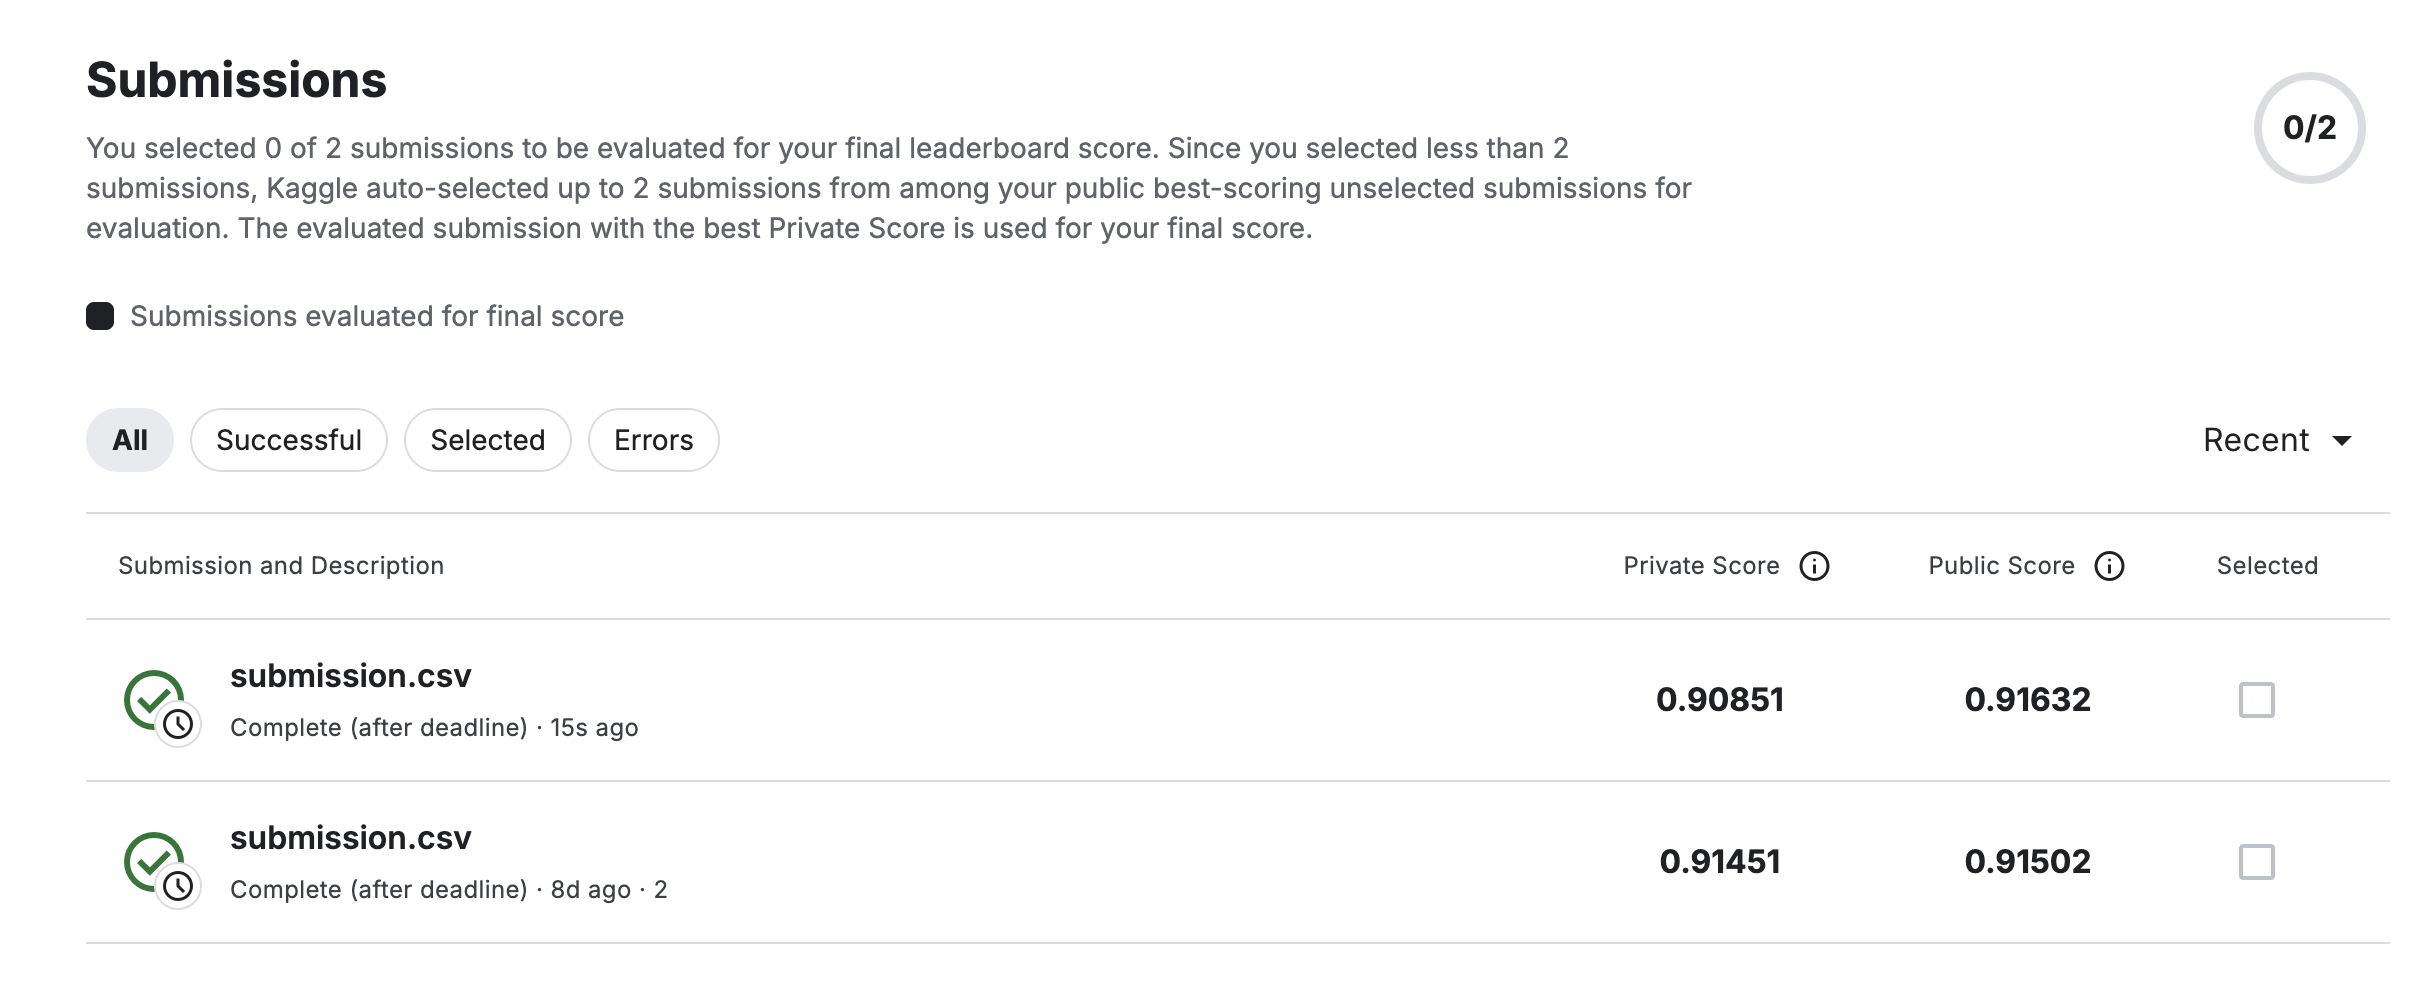